In [2]:
# Import packages
import deeptrack as dt
import numpy as np
import os
import deeplay as dl
import torch
import matplotlib.pyplot as plt
from torch.distributions.normal import Normal

In [4]:
# Define functions and classes
class SimulatedDataset(torch.utils.data.Dataset):
    """Simulated dataset generating pairs of noisy and clean images."""

    def __init__(self, pip, buffer_size, replace=0):
        """Initialize the dataset."""
        self.pip, self.buffer_size, self.replace = pip, buffer_size, replace
        self.images = [pip.update().resolve() for _ in range(buffer_size)]

    def __len__(self):
        """Return the size of the dataset buffer."""
        return self.buffer_size

    def __getitem__(self, idx):
        """Retrieve a noisy-clean image pair from the dataset."""
        if np.random.rand() < self.replace:
            self.images[idx] = self.pip.update().resolve()
        image_pair = self.images[idx]
        noisy_image, clean_image = image_pair[0], image_pair[1]
        return noisy_image, clean_image

# Define microscope to observe particle
brightfield_microscope = dt.Brightfield(wavelength=500 * dt.units.nm, NA=1.0,
    resolution=1 * dt.units.um, magnification=10, refractive_index_medium=1.33, 
    upsample=2, output_region=(0, 0, 64, 64))


# Plot image
def plot_image(title, image):
    """Plot a grayscale image with a title."""
    plt.imshow(image, cmap="gray")
    plt.title(title, fontsize=30)
    plt.axis("off")
    plt.show()


In [5]:
# Create data

# Create particle
particle = dt.Sphere(
    position=lambda: np.array([0.2, 0.2] + np.random.rand(2) * 0.6) * 64, 
    radius=lambda: 500 * dt.units.nm * (1 + np.random.rand()), 
    position_unit="pixel", refractive_index=1.45 + 0.02j)

illuminated_sample = brightfield_microscope(particle)

# Simulate clean particle
clean_particle = illuminated_sample >> dt.NormalizeMinMax() \
    >> dt.MoveAxis(2, 0) >> dt.pytorch.ToTensor(dtype=torch.float)

# Simulate noise
# noise = dt.Poisson(snr=lambda: 2.0 + np.random.rand())

# noisy_particle = illuminated_sample >> noise >> dt.NormalizeMinMax() \
#     >> dt.MoveAxis(2, 0) >> dt.pytorch.ToTensor(dtype=torch.float)

# Create pipeline
image_pip = clean_particle & clean_particle

# Create dataset
dataset = SimulatedDataset(image_pip, buffer_size=256, replace=0.1)
loader = torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=True)


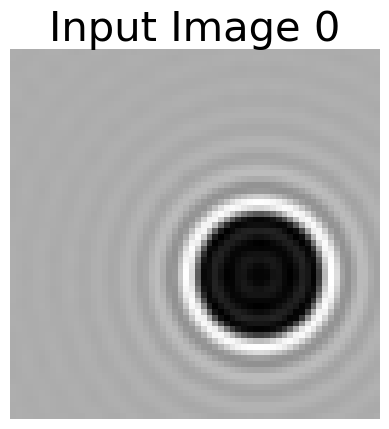

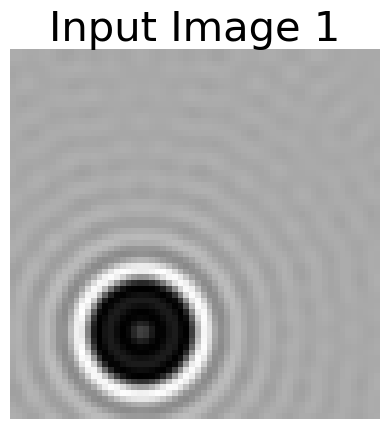

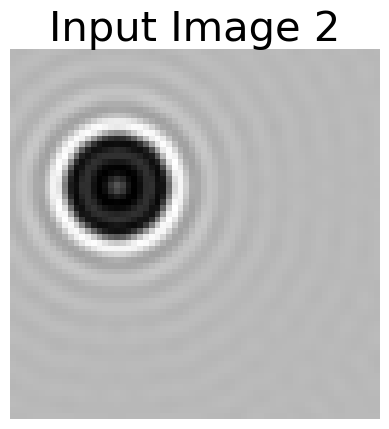

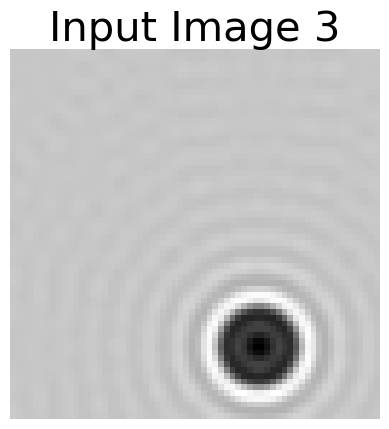

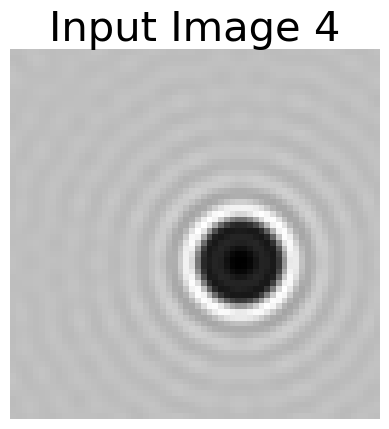

In [6]:
# Plot particles 

for i in range(5):
    input = image_pip.update().resolve()[0]   
    plot_image(f"Input Image {i}", input[0, :, :])

In [30]:
vae_b0 = vae

In [ ]:
# Create autoencoder no beta
vae_b0 = dl.VariationalAutoEncoder(input_size=[64,64], latent_dim=2, channels=[64, 32], reconstruction_loss=torch.nn.BCELoss(reduction="sum"), beta=0, ).create()
vae_b0_trainer = dl.Trainer(max_epochs=50, accelerator="auto") # Configure trainer object

# start training
vae_b0_trainer.fit(vae_b0, loader)

C:\Users\is5046he\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type                   ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ encoder             │ ConvolutionalEncoder2d │ 28.4 K │ train │
│ 1 │ fc_mu               │ Linear                 │ 16.4 K │ train │
│ 2 │ fc_var              │ Linear                 │ 16.4 K │ train │
│ 3 │ fc_dec              │ Linear                 │ 24.6 K │ train │
│ 4 │ decoder             │ ConvolutionalDecoder2d │ 48.9 K │ train │
│ 5 │ reconstruction_loss │ BCELoss                │      0 │ train │
│ 6 │ train_metrics       │ MetricCollection       │      0 │ train │
│ 7 │ val_metrics         │ MetricCollection       │      0 │ train │
│ 8 │ test_metrics        │ MetricCollection       │      0 │ train │
│ 9 │ optimizer           │ Adam                   │      0 │ train │
└───┴─────────────────────┴────────────────────────┴────────┴───────┘

Trainable params: 134 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 134 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 36                                                                                          
Modules in eval mode: 0

Output()

C:\Users\is5046he\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\is5046he\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


In [19]:
# Create autoencoder beta
vae_b1 = dl.VariationalAutoEncoder(input_size=[64,64], latent_dim=3, channels=[64, 32], reconstruction_loss=torch.nn.BCELoss(reduction="sum"), beta=1, ).create()
vae_b1_trainer = dl.Trainer(max_epochs=50, accelerator="auto") # Configure trainer object

# start training
vae_b1_trainer.fit(vae_b1, loader)

C:\Users\is5046he\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type                   ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ encoder             │ ConvolutionalEncoder2d │ 28.4 K │ train │
│ 1 │ fc_mu               │ Linear                 │ 24.6 K │ train │
│ 2 │ fc_var              │ Linear                 │ 24.6 K │ train │
│ 3 │ fc_dec              │ Linear                 │ 32.8 K │ train │
│ 4 │ decoder             │ ConvolutionalDecoder2d │ 48.9 K │ train │
│ 5 │ reconstruction_loss │ BCELoss                │      0 │ train │
│ 6 │ train_metrics       │ MetricCollection       │      0 │ train │
│ 7 │ val_metrics         │ MetricCollection       │      0 │ train │
│ 8 │ test_metrics        │ MetricCollection       │      0 │ train │
│ 9 │ optimizer           │ Adam                   │      0 │ train │
└───┴─────────────────────┴────────────────────────┴────────┴───────┘

Trainable params: 159 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 159 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 36                                                                                          
Modules in eval mode: 0

Output()

C:\Users\is5046he\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\is5046he\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


In [ ]:
# Plot
img_num, img_size = 10, 64
z0_grid = z1_grid = Normal(0, 1).icdf(torch.linspace(0.001, 0.999, img_num))

image = np.zeros((img_num * img_size, img_num * img_size))

for i0, z0 in enumerate(z0_grid):
    for i1, z1 in enumerate(z1_grid):
        z = torch.stack((z0, z1)).unsqueeze(0)
        generated_image = vae.decode(z).clone().detach()
        image[i1 * img_size : (i1 + 1) * img_size,
              i0 * img_size : (i0 + 1) * img_size] = \
            generated_image.numpy().squeeze()


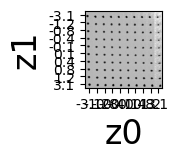

In [ ]:

plt.figure(figsize=(10, 10))
plt.imshow(image, cmap="gray")
plt.xlabel("z0", fontsize=24)
plt.xticks(np.arange(0.5 * img_size, (0.5 + img_num) * img_size, img_size),
           np.round(z0_grid.numpy(), 1))
plt.ylabel("z1", fontsize=24)
plt.yticks(np.arange(0.5 * img_size, (0.5 + img_num) * img_size, img_size),
           np.round(z1_grid.numpy(), 1))
plt.show()

In [20]:
# Plot
img_num, img_size = 10, 64
z0_grid = z1_grid = z2_grid = Normal(0, 1).icdf(torch.linspace(0.001, 0.999, img_num))

image = np.zeros((img_num * img_size, img_num * img_size))

z0_list = []

print("not crashing")

for i0, z0 in enumerate(z0_grid):
    image = np.zeros((img_num * img_size, img_num * img_size))  # Create a new image array for each z0
    for i1, z1 in enumerate(z1_grid):
        for i2, z2 in enumerate(z2_grid):
            z = torch.stack((z0, z1, z2)).unsqueeze(0)
            generated_image = vae_b1.decode(z).clone().detach()
            image[i1 * img_size : (i1 + 1) * img_size,
                  i2 * img_size : (i2 + 1) * img_size] = \
                generated_image.numpy().squeeze()
    z0_list.append(image)
    print(i0)


not crashing
0
1
2
3
4
5
6
7
8
9


0


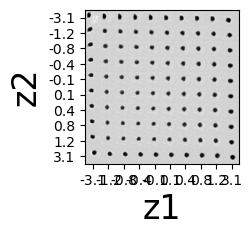

1


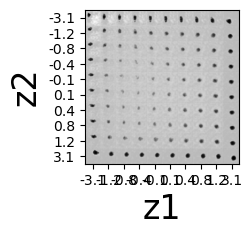

2


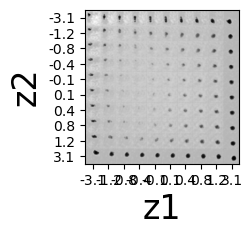

3


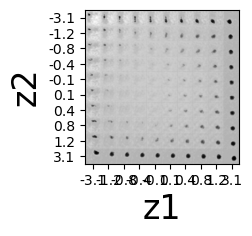

4


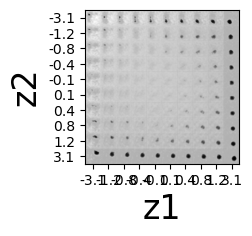

5


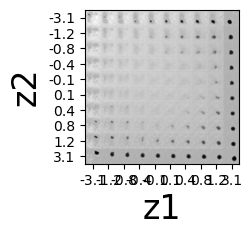

6


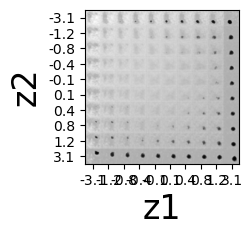

7


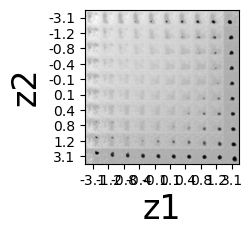

8


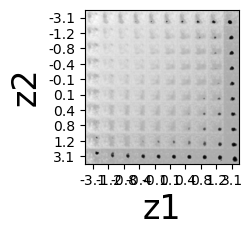

9


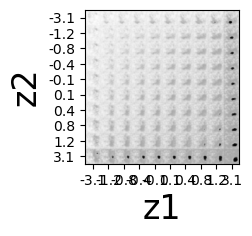

In [17]:
for idx in range(len(z0_list)):
  print(idx)
  plt.figure(figsize=(2, 2))
  plt.imshow(z0_list[idx], cmap="gray")
  plt.xlabel("z1", fontsize=24)
  plt.xticks(np.arange(0.5 * img_size, (0.5 + img_num) * img_size, img_size),
            np.round(z1_grid.numpy(), 1))
  plt.ylabel("z2", fontsize=24)
  plt.yticks(np.arange(0.5 * img_size, (0.5 + img_num) * img_size, img_size),
            np.round(z2_grid.numpy(), 1))
  # plt.title()
  plt.show()

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


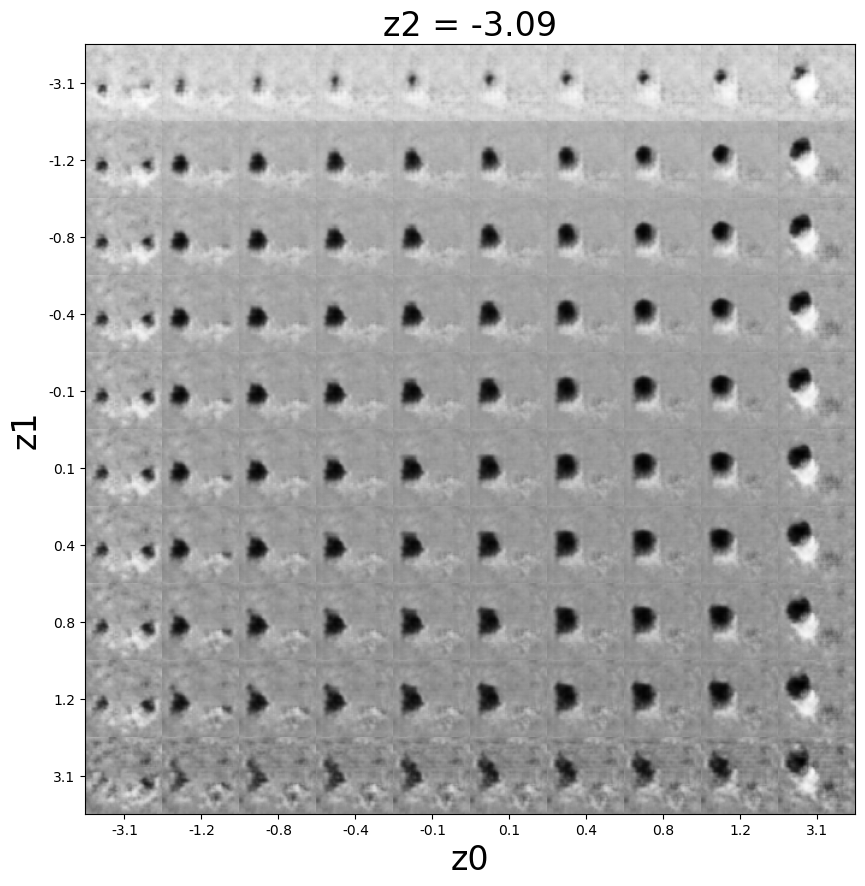

In [21]:
# Now you can create the animation
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(10, 10))

def update(idx):
    ax.clear()
    ax.imshow(z0_list[idx], cmap="gray")
    ax.set_xlabel("z0", fontsize=24)
    ax.set_xticks(np.arange(0.5 * img_size, (0.5 + img_num) * img_size, img_size))
    ax.set_xticklabels(np.round(z0_grid.numpy(), 1))
    ax.set_ylabel("z1", fontsize=24)
    ax.set_yticks(np.arange(0.5 * img_size, (0.5 + img_num) * img_size, img_size))
    ax.set_yticklabels(np.round(z1_grid.numpy(), 1))
    z2_value = z2_grid[idx % len(z2_grid)].item()  # Get the corresponding z2 value
    ax.set_title(f"z2 = {z2_value:.2f}", fontsize=24)

ani = FuncAnimation(fig, update, frames=len(z0_list), interval=1000)  # Update every 1000 ms (1 second)

HTML(ani.to_jshtml())